# CardioIA - Ir Além 2: diagnóstico visual com MLP

Experimento acadêmico de classificação binária de **imagens de batimentos ECG**.
A base [ECG Heartbeat Categorization, versão 1](https://www.kaggle.com/datasets/shayanfazeli/heartbeat)
é a recomendada no enunciado. Ela fornece CSVs de sinais, não fotografias de exames.
Por isso, geramos um traçado de cada sinal, convertemos a imagem para tons de cinza,
redimensionamos para 64×64 pixels e alimentamos uma MLP Keras com os pixels.
Os exemplos públicos são imagens **derivadas desses sinais**, sem nomes de pacientes.

**Escopo dos rótulos:** N (0) é o grupo chamado normal na base; S, V e F (1, 2 e 3)
formam o grupo alterado. Q (4), de batimentos não classificados, é excluída em vez de
ser presumida uma anomalia confirmada. Esses grupos não diagnosticam a saúde de uma pessoa.

**Reproduzir:** na raiz do projeto, instale `requirements-ir-alem2.txt` e execute
`python src/baixar_ecg.py`. Abra este notebook com o kernel **CardioIA ECG (.venv)**
e execute todas as células em ordem. O download mantém os CSVs compactados em `dados/`.
Os hashes do conteúdo original estão em `dados/ecg_origem.json`.

Este experimento não foi validado para diagnóstico ou triagem clínica.

## 1. Ambiente e reprodução

A semente controla seleção, divisão, inicialização, Dropout e embaralhamento.
Usamos CPU, uma thread e operações determinísticas para reduzir variações nesta máquina.
Isso não promete resultados idênticos entre versões, hardware ou sistemas diferentes.

In [9]:
import os
import sys
from pathlib import Path
import importlib.metadata as metadata

# Configurar antes de importar TensorFlow ou NumPy.
for key in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[key] = "1"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["KERAS_BACKEND"] = "tensorflow"

ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
assert (ROOT / "src" / "ecg_imagens.py").is_file(), "Abra o notebook dentro do projeto completo."
sys.path.insert(0, str(ROOT / "src"))

try:
    import tensorflow as tf
    import keras
except ImportError as error:
    raise RuntimeError("Instale requirements-ir-alem2.txt e selecione CardioIA ECG (.venv).") from error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import datetime
from zoneinfo import ZoneInfo
from PIL import Image
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from ecg_imagens import (
    carregar_csv, separar_classes, amostra_balanceada, rasterizar_sinal,
    preprocessar_imagem, sinais_para_imagens, hash_sinais, CLASS_NAMES,
)
from baixar_ecg import arquivo_local, sha256

VERSOES = {package: metadata.version(package) for package in (
    "numpy", "pandas", "scikit-learn", "tensorflow", "keras", "h5py", "ml_dtypes", "pillow", "matplotlib"
)}
assert VERSOES["tensorflow"] == "2.21.0" and VERSOES["keras"] == "3.15.1", VERSOES
assert VERSOES["scikit-learn"] == "1.8.0", "Use o ambiente testado do projeto."
SEMENTE = 42
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.experimental.enable_op_determinism()
keras.utils.set_random_seed(SEMENTE)
tf.get_logger().setLevel("ERROR")
print("Python:", sys.version.split()[0])
print("Pacotes:", VERSOES)
print("Raiz:", ROOT.name, "| Semente:", SEMENTE, "| Execução: CPU")

Python: 3.13.7
Pacotes: {'numpy': '2.3.5', 'pandas': '2.3.3', 'scikit-learn': '1.8.0', 'tensorflow': '2.21.0', 'keras': '3.15.1', 'h5py': '3.14.0', 'ml_dtypes': '0.6.0', 'pillow': '12.0.0', 'matplotlib': '3.10.7'}
Raiz: 2ano_cardioia-fase2-estetoscopio-digital | Semente: 42 | Execução: CPU


## 2. Origem, integridade e rótulos

O loader aceita `dados/mitbih_train.csv` e `dados/mitbih_test.csv`, ou suas versões `.gz`.
Verifica 188 colunas, valores finitos, amplitudes entre 0 e 1 e códigos de classe conhecidos.
As 187 colunas são **amostras temporais de amplitude**, não 187 atributos clínicos independentes.
O CSV do Kaggle já contém sinais segmentados, reamostrados e preenchidos com zeros.

O teste fornecido pelo dataset fica separado do treino. Como os CSVs não trazem
identificadores de pacientes, não podemos verificar independência entre pessoas.
Isso limita conclusões sobre desempenho em novos pacientes.

In [10]:
manifesto = json.loads((ROOT / "dados" / "ecg_origem.json").read_text(encoding="utf-8"))
for nome in ("mitbih_train.csv", "mitbih_test.csv"):
    assert sha256(arquivo_local(nome)) == manifesto["arquivos"][nome]["sha256"], nome
X_origem, rotulos_origem = carregar_csv(ROOT / "dados" / "mitbih_train.csv")
X_teste_origem, rotulos_teste_origem = carregar_csv(ROOT / "dados" / "mitbih_test.csv")
print("Origem conferida: versão", manifesto["versao"], "e SHA-256 dos dois arquivos.")
contagens = pd.DataFrame({
    "classe": [CLASS_NAMES[i] for i in range(5)],
    "treino_original": np.bincount(rotulos_origem, minlength=5),
    "teste_original": np.bincount(rotulos_teste_origem, minlength=5),
})
display(contagens)

Origem conferida: versão 1 e SHA-256 dos dois arquivos.


,classe,treino_original,teste_original
0,N,72471,18118
1,S,2223,556
2,V,5788,1448
3,F,641,162
4,Q,6431,1608


## 3. Divisão e amostra de trabalho

Para viabilizar reprodução em CPU, selecionamos **6.000 batimentos de cada classe binária**
do arquivo de treinamento, sem reposição, após excluir Q e duplicatas exatas.
Essa amostra balanceada tem 12.000 sinais; a divisão estratificada usa 80% para treino
e 20% para validação. O teste preserva a proporção dos rótulos restantes de seu arquivo.
Essa proporção descreve a base, não a prevalência de doenças na população.

O teste não escolhe arquitetura, épocas ou limiar. Duplicatas exatas do sinal já
selecionado para treino/validação são removidas do teste, se existirem, com contagem explícita.
Essa verificação não detecta batimentos apenas semelhantes ou pertencentes à mesma pessoa.

In [11]:
X_pool, y_pool, linhas_pool = separar_classes(X_origem, rotulos_origem)
hashes_pool = hash_sinais(X_pool)
primeiros = {}
conflitos = set()
for posicao, assinatura in enumerate(hashes_pool):
    if assinatura not in primeiros:
        primeiros[assinatura] = posicao
    elif y_pool[posicao] != y_pool[primeiros[assinatura]]:
        conflitos.add(assinatura)
unicos = np.array([pos for assinatura, pos in primeiros.items() if assinatura not in conflitos])
duplicatas_treino = len(X_pool) - len(unicos)
selecionados = unicos[amostra_balanceada(y_pool[unicos], por_classe=6000, seed=SEMENTE)]
X_amostra = X_pool[selecionados]
y_amostra = y_pool[selecionados]
linhas_amostra = linhas_pool[selecionados]
codigos_amostra = rotulos_origem[linhas_amostra]
idx_treino, idx_validacao = train_test_split(
    np.arange(len(y_amostra)), test_size=0.2, random_state=SEMENTE, stratify=y_amostra
)
hashes_amostra = hash_sinais(X_amostra)
assert not set(np.array(hashes_amostra)[idx_treino]) & set(np.array(hashes_amostra)[idx_validacao])

X_teste, y_teste, linhas_teste = separar_classes(X_teste_origem, rotulos_teste_origem)
vistos = set(hashes_amostra)
mascara_teste = np.array([assinatura not in vistos for assinatura in hash_sinais(X_teste)])
duplicatas_teste = int((~mascara_teste).sum())
X_teste, y_teste, linhas_teste = X_teste[mascara_teste], y_teste[mascara_teste], linhas_teste[mascara_teste]
assert len(X_teste) > 0 and len(np.unique(y_teste)) == 2

divisao = pd.concat([
    pd.DataFrame({"arquivo": "mitbih_train.csv", "linha_zero": linhas_amostra[idx_treino], "conjunto": "treino", "classe_original": codigos_amostra[idx_treino], "rotulo_binario": y_amostra[idx_treino]}),
    pd.DataFrame({"arquivo": "mitbih_train.csv", "linha_zero": linhas_amostra[idx_validacao], "conjunto": "validacao", "classe_original": codigos_amostra[idx_validacao], "rotulo_binario": y_amostra[idx_validacao]}),
    pd.DataFrame({"arquivo": "mitbih_test.csv", "linha_zero": linhas_teste, "conjunto": "teste", "classe_original": rotulos_teste_origem[linhas_teste], "rotulo_binario": y_teste}),
], ignore_index=True)
divisao.to_csv(ROOT / "dados" / "ecg_divisao.csv", index=False)
print("Q excluídos: treino", int((rotulos_origem == 4).sum()), "| teste", int((rotulos_teste_origem == 4).sum()))
print("Duplicatas/conflitos excluídos do pool de treino:", duplicatas_treino)
print("Duplicatas de treino/validação excluídas do teste:", duplicatas_teste)
display(pd.crosstab(divisao.conjunto, divisao.rotulo_binario).rename(columns={0: "N", 1: "S/V/F"}))
# Libera as matrizes originais; conservamos apenas os sinais usados no experimento.
del X_origem, X_teste_origem, X_pool, hashes_pool, primeiros

Q excluídos: treino 6431 | teste 1608
Duplicatas/conflitos excluídos do pool de treino: 0
Duplicatas de treino/validação excluídas do teste: 0


rotulo_binario,N,S/V/F
conjunto,,
teste,18118,2166
treino,4800,4800
validacao,1200,1200


## 4. Imagens e pré-processamento

Cada traçado é desenhado em RGB, 256×256 pixels, usando a mesma escala para todos os sinais.
Não há texto, cor de classe ou rótulo dentro dos pixels. A imagem é convertida para
tons de cinza e redimensionada para 64×64 com Lanczos.
As amplitudes de origem já estão entre 0 e 1; não ajustamos escala usando o conjunto de teste.

Os pixels são guardados como uint8 para economizar memória. A camada `Rescaling`
da rede converte em float32 entre 0 e 1 e inverte o fundo: traço claro sobre fundo zero.
`Flatten` transforma os 4.096 pixels em entrada para as camadas densas.
A rasterização é uma adaptação didática à descrição visual do enunciado, não uma fotografia de ECG.

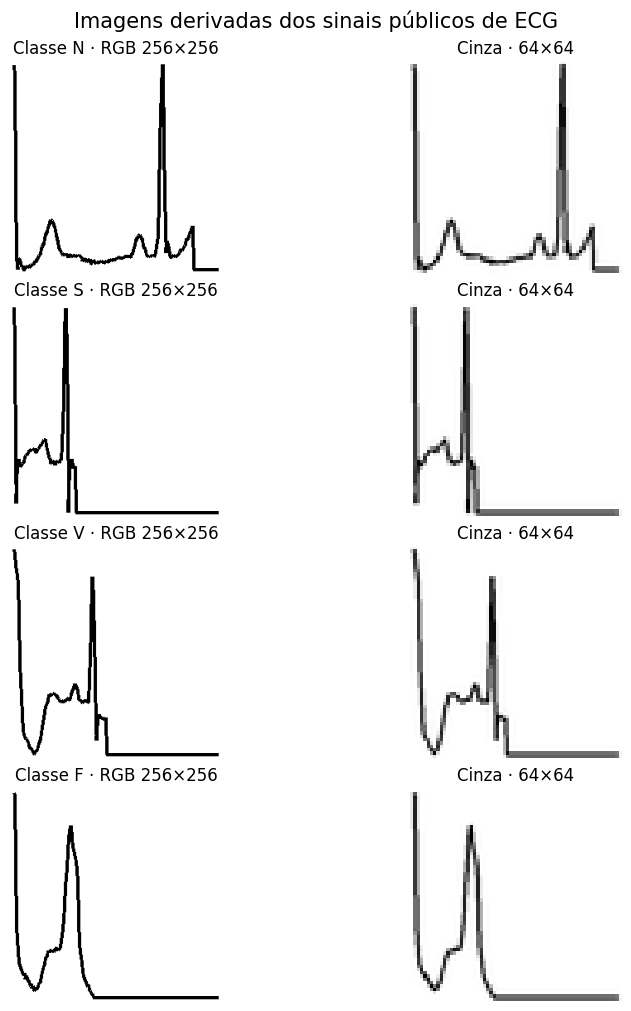

Treino/validação: 4000/12000 imagens
Treino/validação: 8000/12000 imagens
Treino/validação: 12000/12000 imagens
Teste: 4000/20284 imagens
Teste: 8000/20284 imagens
Teste: 12000/20284 imagens
Teste: 16000/20284 imagens
Teste: 20000/20284 imagens
Pixels: (12000, 64, 64, 1) uint8


In [12]:
EXEMPLOS = ROOT / "dados" / "exemplos_ecg"
FIGURAS = ROOT / "docs" / "figuras"
EXEMPLOS.mkdir(exist_ok=True)
FIGURAS.mkdir(exist_ok=True)
fig, axes = plt.subplots(4, 2, figsize=(8, 10), constrained_layout=True)
origens_exemplos = []
for linha_figura, codigo in enumerate((0, 1, 2, 3)):
    posicao = idx_treino[np.flatnonzero(codigos_amostra[idx_treino] == codigo)[0]]
    original = rasterizar_sinal(X_amostra[posicao])
    processada = preprocessar_imagem(original)
    nome = f"{CLASS_NAMES[codigo].lower()}_linha_{int(linhas_amostra[posicao]):06d}"
    original.save(EXEMPLOS / f"{nome}_original.png")
    Image.fromarray(processada[..., 0]).save(EXEMPLOS / f"{nome}_cinza64.png")
    axes[linha_figura, 0].imshow(original)
    axes[linha_figura, 1].imshow(processada[..., 0], cmap="gray", vmin=0, vmax=255)
    axes[linha_figura, 0].set_title(f"Classe {CLASS_NAMES[codigo]} · RGB 256×256")
    axes[linha_figura, 1].set_title("Cinza · 64×64")
    for axis in axes[linha_figura]:
        axis.axis("off")
    origens_exemplos.append({"arquivo": "mitbih_train.csv", "linha_zero": int(linhas_amostra[posicao]), "classe_original": CLASS_NAMES[codigo], "conjunto": "treino", "original": f"{nome}_original.png", "processada": f"{nome}_cinza64.png"})
fig.suptitle("Imagens derivadas dos sinais públicos de ECG", fontsize=15)
fig.savefig(FIGURAS / "ecg_exemplos.png", dpi=150)
plt.show()
plt.close(fig)
(EXEMPLOS / "origem.json").write_text(json.dumps(origens_exemplos, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
imagens_amostra = sinais_para_imagens(X_amostra, "Treino/validação")
imagens_teste = sinais_para_imagens(X_teste, "Teste")
print("Pixels:", imagens_amostra.shape, imagens_amostra.dtype)
assert imagens_amostra.shape == (12000, 64, 64, 1)
del X_amostra, X_teste

## 5. MLP Keras e treinamento

Arquitetura: normalização dos pixels → Flatten → Dense 128 → Dropout 0,3 → Dense 64
→ Dropout 0,2 → Dense 32 → Dense 1 com Sigmoid.
Usamos Adam, perda binary cross-entropy, lotes de 64 e **10 épocas fixas**.
Dropout é uma medida de regularização; sua presença não comprova ausência de sobreajuste.
O limiar binário fica fixado em 0,5 antes da avaliação final.

In [13]:
# Reiniciar a aleatoriedade no início da célula de treinamento.
# A interação com outras células não deve alterar a inicialização.
keras.utils.set_random_seed(SEMENTE)

options = tf.data.Options()
options.experimental_deterministic = True
options.threading.private_threadpool_size = 1
options.threading.max_intra_op_parallelism = 1
def dataset(imagens, rotulos=None, treino=False):
    valores = imagens if rotulos is None else (imagens, rotulos)
    ds = tf.data.Dataset.from_tensor_slices(valores)
    if treino:
        ds = ds.shuffle(len(imagens), seed=SEMENTE, reshuffle_each_iteration=True)
    return ds.batch(64).with_options(options).prefetch(1)

ds_treino = dataset(imagens_amostra[idx_treino], y_amostra[idx_treino], treino=True)
ds_validacao = dataset(imagens_amostra[idx_validacao], y_amostra[idx_validacao])
modelo_mlp = keras.Sequential([
    keras.layers.Input(shape=(64, 64, 1), dtype="uint8"),
    keras.layers.Rescaling(-1.0 / 255.0, offset=1.0),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu", kernel_initializer=keras.initializers.GlorotUniform(seed=42)),
    keras.layers.Dropout(0.3, seed=43),
    keras.layers.Dense(64, activation="relu", kernel_initializer=keras.initializers.GlorotUniform(seed=44)),
    keras.layers.Dropout(0.2, seed=45),
    keras.layers.Dense(32, activation="relu", kernel_initializer=keras.initializers.GlorotUniform(seed=46)),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.GlorotUniform(seed=47)),
], name="cardioia_mlp_imagens")
modelo_mlp.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=[keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)])
modelo_mlp.summary()
historico = modelo_mlp.fit(ds_treino, validation_data=ds_validacao, epochs=10, verbose=2)

Model: "cardioia_mlp_imagens"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 534,785 (2.04 MB)

 Trainable params: 534,785 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


C:\Users\Malu\Documents\fiap\2ano_cardioia-fase2-estetoscopio-digital\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


150/150 - 2s - 12ms/step - accuracy: 0.8576 - loss: 0.3295 - val_accuracy: 0.8967 - val_loss: 0.2486
Epoch 2/10
150/150 - 1s - 7ms/step - accuracy: 0.9242 - loss: 0.1976 - val_accuracy: 0.9192 - val_loss: 0.2051
Epoch 3/10
150/150 - 1s - 7ms/step - accuracy: 0.9408 - loss: 0.1562 - val_accuracy: 0.9283 - val_loss: 0.1946
Epoch 4/10
150/150 - 1s - 8ms/step - accuracy: 0.9503 - loss: 0.1355 - val_accuracy: 0.9267 - val_loss: 0.2026
Epoch 5/10
150/150 - 1s - 7ms/step - accuracy: 0.9585 - loss: 0.1100 - val_accuracy: 0.9304 - val_loss: 0.2223
Epoch 6/10
150/150 - 1s - 8ms/step - accuracy: 0.9642 - loss: 0.0927 - val_accuracy: 0.9367 - val_loss: 0.1951
Epoch 7/10
150/150 - 1s - 7ms/step - accuracy: 0.9684 - loss: 0.0819 - val_accuracy: 0.9375 - val_loss: 0.1878
Epoch 8/10
150/150 - 1s - 7ms/step - accuracy: 0.9734 - loss: 0.0709 - val_accuracy: 0.9342 - val_loss: 0.2248
Epoch 9/10
150/150 - 1s - 7ms/step - accuracy: 0.9793 - loss: 0.0574 - val_accuracy: 0.9383 - val_loss: 0.2199
Epoch 10/10

## 6. Histórico e consistência da validação

Conferimos que a avaliação do modelo atual coincide com a última época salva.
Isso evita reutilizar resultados de uma execução anterior ao treinamento.
Os gráficos descrevem esta amostra e esta execução; não constituem validação clínica.

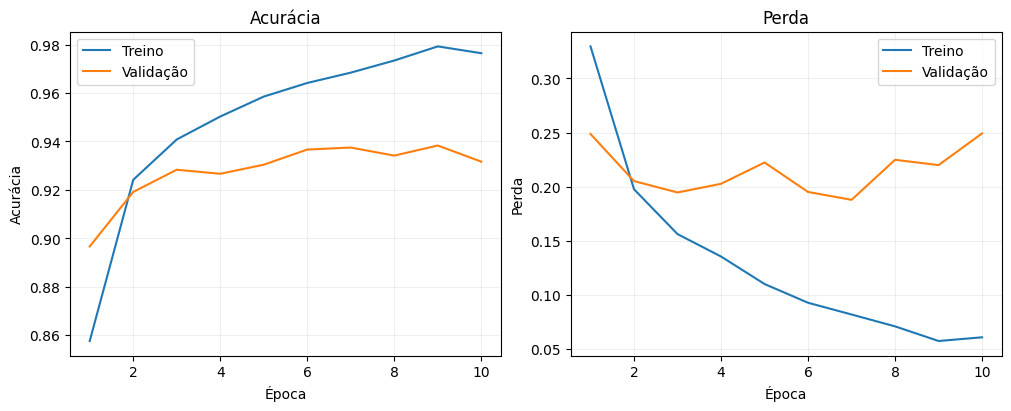

Validação do modelo atual: 93.1667%; conferida com a última época.


In [14]:
avaliacao_validacao = modelo_mlp.evaluate(ds_validacao, verbose=0, return_dict=True)
assert np.isclose(avaliacao_validacao["accuracy"], historico.history["val_accuracy"][-1], atol=1e-6)
hist_df = pd.DataFrame(historico.history)
hist_df.index = np.arange(1, len(hist_df) + 1)
hist_df.index.name = "epoca"
hist_df.to_csv(ROOT / "dados" / "ecg_historico.csv")
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for axis, metrica, titulo in zip(axes, ("accuracy", "loss"), ("Acurácia", "Perda")):
    axis.plot(hist_df.index, hist_df[metrica], label="Treino")
    axis.plot(hist_df.index, hist_df["val_" + metrica], label="Validação")
    axis.set(xlabel="Época", ylabel=titulo, title=titulo)
    axis.grid(alpha=0.2)
    axis.legend()
fig.savefig(FIGURAS / "ecg_treinamento.png", dpi=150)
plt.show()
plt.close(fig)
print(f"Validação do modelo atual: {avaliacao_validacao['accuracy']:.4%}; conferida com a última época.")

## 7. Teste separado, matriz de confusão e interpretação

A avaliação abaixo usa o arquivo de teste, sem balanceá-lo ou usá-lo durante o treino.
Precisão = TP/(TP+FP): fração dos alertas de alteração que correspondem ao grupo S/V/F.
Taxa de falsos positivos = FP/(FP+TN): fração do grupo N classificada como alterada.
Essas taxas têm denominadores diferentes. Recall = TP/(TP+FN).
Apresentamos as contagens para tornar os erros visíveis.

,precision,recall,f1-score,support
N,0.990766,0.947566,0.968685,18118.000000
S/V/F,0.678620,0.926131,0.783288,2166.000000
accuracy,0.945277,0.945277,0.945277,0.945277
macro avg,0.834693,0.936849,0.875986,20284.000000
weighted avg,0.957434,0.945277,0.948887,20284.000000


,previsto_N,previsto_SVF
N_real,17168,950
SVF_real,160,2006


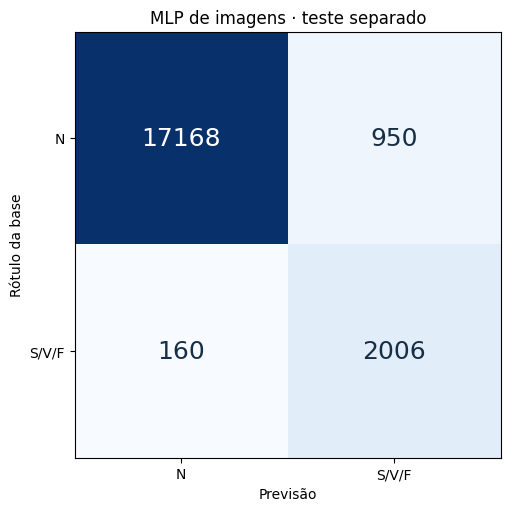


**Teste:** 20,284 batimentos; acurácia **94.53%**.
Precisão do grupo alterado: **67.86%**; recall: **92.61%**; F1: **0.7833**.
**Erros:** 950 falsos positivos e 160 falsos negativos.
Taxa de falsos positivos entre os N: **5.24%**.
Fração de alertas incorretos entre as previsões S/V/F: **32.14%**.
A regra que sempre prevê N teria **89.32%** de acurácia e zero recall do grupo alterado.


In [15]:
probabilidades_teste = modelo_mlp.predict(dataset(imagens_teste), verbose=0).ravel()
LIMIAR = 0.5
previsoes_teste = (probabilidades_teste > LIMIAR).astype(np.int32)
matriz = confusion_matrix(y_teste, previsoes_teste, labels=[0, 1])
tn, fp, fn, tp = (int(valor) for valor in matriz.ravel())
acuracia_teste = accuracy_score(y_teste, previsoes_teste)
precisao_alterado = tp / (tp + fp) if tp + fp else 0.0
recall_alterado = tp / (tp + fn)
f1_alterado = 2 * tp / (2 * tp + fp + fn)
taxa_falsos_positivos = fp / (fp + tn)
fracao_alertas_incorretos = fp / (fp + tp) if fp + tp else 0.0
acuracia_referencia = float(np.mean(y_teste == 0))
relatorio = classification_report(y_teste, previsoes_teste, labels=[0, 1], target_names=["N", "S/V/F"], output_dict=True, zero_division=0)
display(pd.DataFrame(relatorio).transpose())
matriz_df = pd.DataFrame(matriz, index=["N_real", "SVF_real"], columns=["previsto_N", "previsto_SVF"])
display(matriz_df)
matriz_df.to_csv(ROOT / "dados" / "ecg_matriz_confusao.csv", index_label="rotulo_real")
pd.DataFrame(relatorio).transpose().to_csv(ROOT / "dados" / "ecg_metricas_classes.csv", index_label="classe")
fig, axis = plt.subplots(figsize=(6, 5), constrained_layout=True)
axis.imshow(matriz, cmap="Blues")
for i in range(2):
    for j in range(2):
        axis.text(j, i, str(matriz[i, j]), ha="center", va="center", fontsize=18, color="white" if matriz[i, j] > matriz.max() / 2 else "#172f46")
axis.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["N", "S/V/F"], yticklabels=["N", "S/V/F"], xlabel="Previsão", ylabel="Rótulo da base", title="MLP de imagens · teste separado")
fig.savefig(FIGURAS / "ecg_matriz_confusao.png", dpi=150)
plt.show()
plt.close(fig)
display(Markdown(f"""
**Teste:** {len(y_teste):,} batimentos; acurácia **{acuracia_teste:.2%}**.
Precisão do grupo alterado: **{precisao_alterado:.2%}**; recall: **{recall_alterado:.2%}**; F1: **{f1_alterado:.4f}**.
**Erros:** {fp} falsos positivos e {fn} falsos negativos.
Taxa de falsos positivos entre os N: **{taxa_falsos_positivos:.2%}**.
Fração de alertas incorretos entre as previsões S/V/F: **{fracao_alertas_incorretos:.2%}**.
A regra que sempre prevê N teria **{acuracia_referencia:.2%}** de acurácia e zero recall do grupo alterado.
"""))

## 8. Exportação e conferência do modelo salvo

O modelo é salvo localmente, recarregado e suas previsões são comparadas.
O repositório distribui o código e resultados, sem os CSVs grandes nem o modelo binário.
O relatório JSON registra as versões, configuração e contagens da execução.

In [16]:
MODELOS = ROOT / "modelos"
MODELOS.mkdir(exist_ok=True)
caminho_modelo = MODELOS / "cardioia_ecg.keras"
modelo_mlp.save(caminho_modelo)
recarregado = keras.models.load_model(caminho_modelo)
prob_recarregadas = recarregado.predict(dataset(imagens_teste[:128]), verbose=0).ravel()
assert np.allclose(prob_recarregadas, probabilidades_teste[:128], atol=1e-6)
assert np.array_equal((prob_recarregadas > LIMIAR).astype(np.int32), previsoes_teste[:128])
assert np.array_equal(previsoes_teste[:128], (modelo_mlp.predict(dataset(imagens_teste[:128]), verbose=0).ravel() > LIMIAR).astype(np.int32))
del recarregado
resultado = {
    "experimento": "MLP de imagens rasterizadas de ECG; N versus S/V/F; Q excluída",
    "data_validacao": datetime.now(ZoneInfo("America/Bahia")).date().isoformat(), "python": sys.version.split()[0], "versoes": VERSOES,
    "semente": SEMENTE, "epocas": 10, "batch_size": 64, "limiar": LIMIAR,
    "imagem": {"original_rgb": [256, 256], "cinza": [64, 64], "entrada": "pixels uint8; Rescaling(-1/255, offset=1); Flatten"},
    "treino": len(idx_treino), "validacao": len(idx_validacao), "teste": len(y_teste),
    "q_excluidos_treino": int((rotulos_origem == 4).sum()), "q_excluidos_teste": int((rotulos_teste_origem == 4).sum()),
    "duplicatas_conflitos_excluidos_pool_treino": duplicatas_treino,
    "duplicatas_treino_validacao_excluidas_teste": duplicatas_teste,
    "acuracia_validacao": float(avaliacao_validacao["accuracy"]),
    "acuracia_teste": float(acuracia_teste), "precisao_alterado": precisao_alterado,
    "recall_alterado": recall_alterado, "f1_alterado": f1_alterado,
    "taxa_falsos_positivos": taxa_falsos_positivos, "fracao_alertas_incorretos": fracao_alertas_incorretos,
    "matriz_confusao_N_SVF": matriz.tolist(), "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    "acuracia_referencia_sempre_N": acuracia_referencia,
    "origem": "dados/ecg_origem.json", "selecao": "dados/ecg_divisao.csv",
    "previsoes_estaveis_recarregando_modelo": True,
}
(ROOT / "dados" / "ecg_resultados.json").write_text(json.dumps(resultado, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
print("Modelo salvo e recarregado com previsões conferidas.")
print("Resultados: dados/ecg_resultados.json; histórico, métricas e matriz em CSV.")

Modelo salvo e recarregado com previsões conferidas.
Resultados: dados/ecg_resultados.json; histórico, métricas e matriz em CSV.


## 9. Limitações, governança e entrega

- A amostra de treino é balanceada; o teste conserva a distribuição dos rótulos restantes
  do arquivo de teste. Nenhuma delas representa automaticamente uma população clínica.
- N, S, V e F são categorias de batimentos. A classificação não diagnostica uma pessoa,
  não identifica todas as doenças e não substitui a interpretação de um ECG completo.
- Q é excluída; o modelo não aprende a rejeitar sinais desconhecidos ou inválidos.
- A divisão não é comprovadamente independente por paciente, porque o CSV não traz seus IDs.
- A rasterização e a resolução de 64×64 podem perder detalhes. Os traçados têm escala uniforme
  e não representam fotografias, ruído de câmera, papel de ECG ou equipamentos diferentes.
- A saída Sigmoid é uma estimativa do classificador. Não medimos calibração nem risco clínico.
- A presença de Dropout, uma boa acurácia ou uma boa precisão não garante segurança clínica.
- Comparamos à referência majoritária e mostramos os falsos negativos, sem ocultá-los na acurácia.

O documento [de governança](../docs/GOVERNANCA_IR_ALEM2.md) detalha os limites.
O [roteiro de gravação](../docs/roteiro_video_ir_alem2.md) orienta um vídeo de até quatro minutos.
O vídeo deve ser publicado como não listado e seu link incluído no README; continua pendente.

Referências: [base recomendada](https://www.kaggle.com/datasets/shayanfazeli/heartbeat),
[MIT-BIH original](https://physionet.org/content/mitdb/1.0.0/),
[artigo da preparação dos sinais](https://arxiv.org/abs/1805.00794),
[reprodução em Keras](https://keras.io/examples/keras_recipes/reproducibility_recipes/),
[precisão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html).